In [1]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata
import os
from collections import Counter
from sklearn.decomposition import PCA


#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# import seaborn as sns
import anndata
from scipy import stats
import warnings 
import logging
import seaborn as sns

working_dic="/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/PCMV/"
os.chdir(working_dic)

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.logging.print_version_and_date()

sc.settings.verbosity = 1
warnings.filterwarnings('ignore')

# If you're using libraries like pandas, you can also set their display options
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#FF0000"])

plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs


Running Scanpy 1.11.5, on 2025-12-03 12:41.


In [2]:
adata_ann = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/Humanxeno_annot.h5ad')

In [3]:
adata_raw = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/Humanxeno_preprocessed_mtfilter_1_ribofilter.h5ad')

In [4]:
import pandas as pd

# 1) Check that the cells match between the two objects
print("Same cells in same order?", (adata_ann.obs_names == adata_raw.obs_names).all())
print("Same set of cells?", set(adata_ann.obs_names) == set(adata_raw.obs_names))

# 2) Create a Series of cell_type indexed by cell barcode
cell_type_series = adata_ann.obs['cell_type']

# 3) Align by index and assign to adata_raw.obs
adata_raw.obs['cell_type'] = cell_type_series.reindex(adata_raw.obs_names)


# 4) Quick sanity check
print(adata_raw.obs['cell_type'].head())
print(adata_raw.obs['cell_type'].isna().sum(), "cells with NA cell_type (should be 0 if perfect match)")


Same cells in same order? True
Same set of cells? True
CATCGGGGTGGTAATA-1-0    CM
GTTCGCTTCTGCGTCT-1-0    CM
TTCATTGTCTTGGAAC-1-0    CM
AACTTCTCAAATGAAC-1-0    CM
TTCTAACGTTCTGACA-1-0    CM
Name: cell_type, dtype: category
Categories (11, object): ['CM', 'EC', 'Endocardial_Lymphatic_EC', 'Fibroblasts', ..., 'Myeloids_human', 'Neuronal_cells', 'Pericyte', 'SMC']
0 cells with NA cell_type (should be 0 if perfect match)


In [5]:
import pandas as pd
import numpy as np

# 1) Check that the cells match between the two objects
same_order = (adata_ann.obs_names == adata_raw.obs_names).all()
same_set = set(adata_ann.obs_names) == set(adata_raw.obs_names)

print("Same cells in same order? ", same_order)
print("Same set of cells?      ", same_set)

if not same_set:
    raise ValueError("adata_ann and adata_raw do not have the same cell barcodes!")

# If order differs, reorder adata_ann to match adata_raw
if not same_order:
    print("Reordering adata_ann to match adata_raw.obs_names...")
    adata_ann = adata_ann[adata_raw.obs_names, :]

# 2) Transfer cell_type
adata_raw.obs['cell_type'] = adata_ann.obs['cell_type'].copy()

# 3) Transfer X_umap
if 'X_umap' in adata_ann.obsm:
    adata_raw.obsm['X_umap'] = adata_ann.obsm['X_umap'].copy()
    print("Transferred X_umap from adata_ann to adata_raw.")
else:
    print("Warning: adata_ann.obsm does not contain 'X_umap'.")

# 4) Quick sanity check
print(adata_raw.obs['cell_type'].head())
print(adata_raw.obs['cell_type'].isna().sum(), "cells with NA cell_type (should be 0 if perfect match)")


Same cells in same order?  True
Same set of cells?       True
Transferred X_umap from adata_ann to adata_raw.
CATCGGGGTGGTAATA-1-0    CM
GTTCGCTTCTGCGTCT-1-0    CM
TTCATTGTCTTGGAAC-1-0    CM
AACTTCTCAAATGAAC-1-0    CM
TTCTAACGTTCTGACA-1-0    CM
Name: cell_type, dtype: category
Categories (11, object): ['CM', 'EC', 'Endocardial_Lymphatic_EC', 'Fibroblasts', ..., 'Myeloids_human', 'Neuronal_cells', 'Pericyte', 'SMC']
0 cells with NA cell_type (should be 0 if perfect match)


In [8]:
adata_raw.var

,gene_ids,feature_types,genome,hs_mt,ss_mt,hs_ribo,ss_ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
Homo_sapiens_ENSG00000238009,Homo_sapiens_ENSG00000238009,Gene Expression,Homo_sapiens,False,False,False,False,16,0.000631,0.000631,99.936906,16.0,2.833213,14
Homo_sapiens_ENSG00000241860,Homo_sapiens_ENSG00000241860,Gene Expression,Homo_sapiens,False,False,False,False,41,0.001656,0.001655,99.838322,42.0,3.761200,31
Homo_sapiens_ENSG00000290385,Homo_sapiens_ENSG00000290385,Gene Expression,Homo_sapiens,False,False,False,False,37,0.001459,0.001458,99.854095,37.0,3.637586,33
Homo_sapiens_ENSG00000291215,Homo_sapiens_ENSG00000291215,Gene Expression,Homo_sapiens,False,False,False,False,58,0.002366,0.002363,99.771284,60.0,4.110874,48
Homo_sapiens_LINC01409,Homo_sapiens_ENSG00000237491,Gene Expression,Homo_sapiens,False,False,False,False,144,0.006270,0.006250,99.432154,159.0,5.075174,107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sus_scrofa___exon-P379_gp76,Sus_scrofa___exon-P379_gp76,Gene Expression,Sus_scrofa,False,False,False,False,26,0.001656,0.001655,99.897472,42.0,3.761200,13
Sus_scrofa___exon-P379_gp77,Sus_scrofa___exon-P379_gp77,Gene Expression,Sus_scrofa,False,False,False,False,7,0.000394,0.000394,99.972396,10.0,2.397895,5
Sus_scrofa___exon-P379_gp78,Sus_scrofa___exon-P379_gp78,Gene Expression,Sus_scrofa,False,False,False,False,60,0.007966,0.007934,99.763398,202.0,5.313206,20
Sus_scrofa___exon-P379_gp79,Sus_scrofa___exon-P379_gp79,Gene Expression,Sus_scrofa,False,False,False,False,53,0.005363,0.005349,99.791001,136.0,4.919981,19


In [6]:
import numpy as np
from scipy.sparse import issparse

# 1) Identify PCMV genes in var
pcmv_gene_mask = adata_raw.var_names.str.startswith('Sus_scrofa___exon-')
pcmv_genes = adata_raw.var_names[pcmv_gene_mask]
print(f"Found {pcmv_gene_mask.sum()} PCMV genes.")

# 2) Extract the submatrix with only PCMV genes
X_pcmv = adata_raw[:, pcmv_gene_mask].X  # shape: n_cells x n_pcmv_genes

# 3) Compute per-cell totals and unique gene counts
if issparse(X_pcmv):
    # Total PCMV counts per cell
    n_counts_pCMV = np.asarray(X_pcmv.sum(axis=1)).ravel()
    # Number of PCMV genes detected per cell (count > 0)
    n_genes_pCMV = np.asarray((X_pcmv > 0).sum(axis=1)).ravel()
else:
    n_counts_pCMV = X_pcmv.sum(axis=1)
    n_genes_pCMV = (X_pcmv > 0).sum(axis=1)

# 4) Add to obs
adata_raw.obs['n_counts_pCMV'] = n_counts_pCMV
adata_raw.obs['n_genes_pCMV'] = n_genes_pCMV

# Optional sanity check
print(adata_raw.obs[['n_counts_pCMV', 'n_genes_pCMV']].head())


Found 78 PCMV genes.
                      n_counts_pCMV  n_genes_pCMV
CATCGGGGTGGTAATA-1-0            0.0             0
GTTCGCTTCTGCGTCT-1-0            1.0             1
TTCATTGTCTTGGAAC-1-0            0.0             0
AACTTCTCAAATGAAC-1-0            0.0             0
TTCTAACGTTCTGACA-1-0            0.0             0


In [7]:
import scanpy as sc


adata_raw.raw = adata_raw.copy()

# Make sure you already have this:
# pcmv_genes = adata_raw.var_names[adata_raw.var_names.str.startswith('Sus_scrofa___exon-')]

# Skip scoring if no PCMV genes
if len(pcmv_genes) == 0:
    adata_raw.obs['pCMV_score'] = 0.0
    print("No PCMV genes found. Score set to 0 for all cells.")
else:
    # Normalize and log1p (non-destructive; doesn't affect .raw)
    sc.pp.normalize_total(adata_raw, target_sum=1e4)
    sc.pp.log1p(adata_raw)

    # Score genes — works on normalized/log1p data in .X
    sc.tl.score_genes(
        adata_raw,
        gene_list=pcmv_genes.tolist(),  # convert Index to list
        score_name='pCMV_score',
        random_state=42
    )

    print("✅ pCMV_score calculated and stored in adata_raw.obs['pCMV_score']")


✅ pCMV_score calculated and stored in adata_raw.obs['pCMV_score']


In [8]:
# Define pCMV infection thresholds to remove potential artifacts
pcmv_thresholds = {
    'pCMV_positivity_threshold': {
        'n_counts_pCMV': 10,  # Minimum UMIs
        'n_genes_pCMV': 2,    # Minimum genes
        'description': 'Stringent: ≥10 UMIs + ≥2 genes'
    }
}

# Apply thresholds to AnnData object
for threshold_name, criteria in pcmv_thresholds.items():
    infection_condition = (
        (adata_raw.obs['n_counts_pCMV'] >= criteria['n_counts_pCMV']) & 
        (adata_raw.obs['n_genes_pCMV'] >= criteria['n_genes_pCMV'])
    )
    adata_raw.obs[threshold_name] = infection_condition
    
    # Print verification
    print(f"\n{threshold_name} ({criteria['description']}):")
    print(adata_raw.obs[threshold_name].value_counts())


pCMV_positivity_threshold (Stringent: ≥10 UMIs + ≥2 genes):
pCMV_positivity_threshold
False    20265
True        24
Name: count, dtype: int64


In [9]:
adata_raw.write ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/Humanxeno_lognormalized_with_raw_as_RAWRAW_pcmv_metrics.h5ad')

In [10]:
pcmv_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/Humanxeno_lognormalized_with_raw_as_RAWRAW_pcmv_metrics.h5ad')

In [11]:
pcmv_adata

AnnData object with n_obs × n_vars = 20289 × 36545
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_hs_mt', 'log1p_total_counts_hs_mt', 'pct_counts_hs_mt', 'total_counts_hs_ribo', 'log1p_total_counts_hs_ribo', 'pct_counts_hs_ribo', 'total_counts_ss_mt', 'log1p_total_counts_ss_mt', 'pct_counts_ss_mt', 'total_counts_ss_ribo', 'log1p_total_counts_ss_ribo', 'pct_counts_ss_ribo', 'cell_type', 'n_counts_pCMV', 'n_genes_pCMV', 'pCMV_score', 'pCMV_positivity_threshold'
    var: 'gene_ids', 'feat

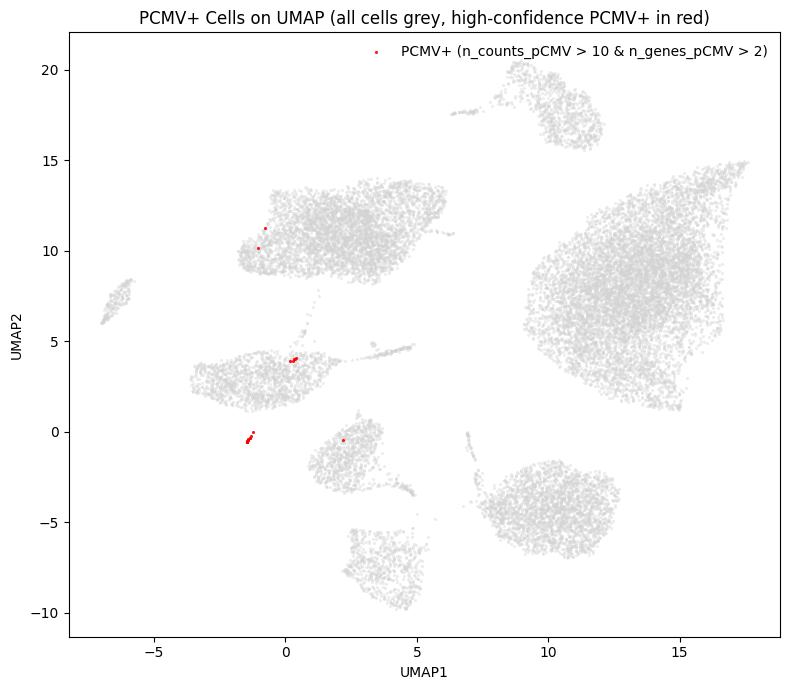

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get UMAP coordinates
umap = pcmv_adata.obsm["X_umap"]

# Boolean mask for PCMV+ cells with stricter thresholds
pcmv_pos = (
    (pcmv_adata.obs["n_counts_pCMV"] > 10) &
    (pcmv_adata.obs["n_genes_pCMV"] > 2)
)

plt.figure(figsize=(8, 7))

# 1) Plot ALL cells in light grey
sns.scatterplot(
    x=umap[:, 0],
    y=umap[:, 1],
    color="lightgrey",
    s=5,
    alpha=0.4,
    linewidth=0
)

# 2) Overlay ONLY PCMV+ cells in red (meeting both thresholds)
sns.scatterplot(
    x=umap[pcmv_pos, 0],
    y=umap[pcmv_pos, 1],
    color="red",
    s=5,
    alpha=0.9,
    linewidth=0,
    label="PCMV+ (n_counts_pCMV > 10 & n_genes_pCMV > 2)"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("PCMV+ Cells on UMAP (all cells grey, high-confidence PCMV+ in red)")
plt.legend(loc="upper right", frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
##### import scanpy as sc

# Ensure cell_type is categorical (helps with nicer plotting)
pcmv_adata.obs['cell_type'] = pcmv_adata.obs['cell_type'].astype('category')

sc.pl.umap(
    pcmv_adata,
    color='cell_type',
    legend_loc='on data',   # <-- puts cell type names inside the UMAP
    legend_fontsize=8,
    legend_fontoutline=2,
    size=10,
    frameon=False
)


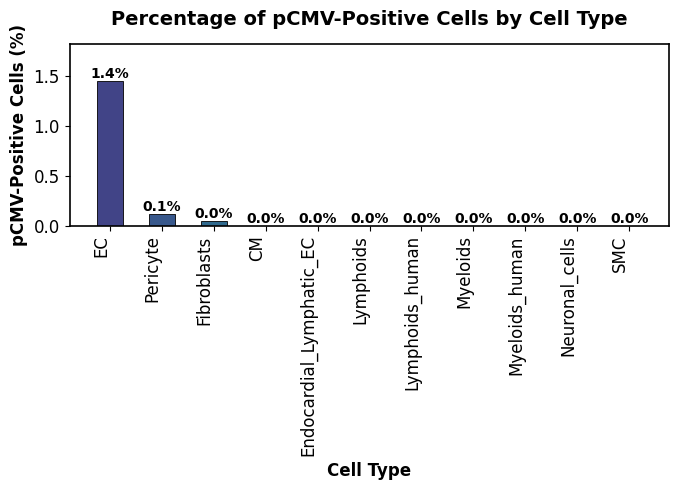

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Use your already-loaded AnnData object ---
# pcmv_adata = sc.read('...Humanxeno_lognormalized_with_raw_as_RAWRAW_pcmv_metrics.h5ad')

# --- Make sure the positivity column exists ---
colname = 'pCMV_positivity_threshold'
if colname not in pcmv_adata.obs:
    raise KeyError(f"Column '{colname}' not found in .obs.")

col = pcmv_adata.obs[colname]

# --- Coerce to numeric 0/1 like in your previous workflow ---
if pd.api.types.is_bool_dtype(col):
    pcmv_pos_num = col.astype(int)
elif pd.api.types.is_numeric_dtype(col):
    pcmv_pos_num = col.astype(int)
else:
    parsed = col.astype(str).str.strip().str.lower().map({
        'true': 1, 'false': 0, '1': 1, '0': 0,
        'yes': 1, 'no': 0, 'y': 1, 'n': 0
    })
    pcmv_pos_num = parsed.fillna(0).astype(int)

pcmv_adata.obs['pCMV_pos_num'] = pcmv_pos_num

# --- Check cell_type column and compute % positive per cell type ---
celltype_col = 'cell_type'
if celltype_col not in pcmv_adata.obs:
    raise KeyError(f"Column '{celltype_col}' not found in .obs.")

infection_percentages = pcmv_adata.obs.groupby(celltype_col)['pCMV_pos_num'].mean() * 100
infection_percentages_df = (
    infection_percentages
    .reset_index()
    .rename(columns={'pCMV_pos_num': 'percentage_pCMV_positive'})
    .sort_values('percentage_pCMV_positive', ascending=False)
)
cell_type_order = infection_percentages_df[celltype_col].tolist()

# --- Plot (matplotlib only) ---
plt.figure(figsize=(7, 5))
x = np.arange(len(cell_type_order))
y = infection_percentages_df.set_index(celltype_col).loc[
    cell_type_order, 'percentage_pCMV_positive'
].values

bars = plt.bar(x, y, width=0.5)
plt.title('Percentage of pCMV-Positive Cells by Cell Type', fontsize=14, fontweight='bold', pad=14)
plt.xlabel('Cell Type', fontsize=12, fontweight='bold')
plt.ylabel('pCMV-Positive Cells (%)', fontsize=12, fontweight='bold')
plt.xticks(x, cell_type_order, rotation=90, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# y-limit headroom for labels above bars
ymax = (np.nanmax(y) if len(y) else 0) * 1.25
plt.ylim(0, max(1, ymax))

# --- Apply colorblind-safe Viridis gradient and crisp edges ---
colors = cm.get_cmap("viridis")(np.linspace(0.2, 0.9, len(bars)))
for rect, color in zip(bars, colors):
    rect.set_color(color)
    rect.set_edgecolor("black")
    rect.set_linewidth(0.6)

# --- Put percentage labels ABOVE each bar ---
ax = plt.gca()
axis_range = ax.get_ylim()[1] - ax.get_ylim()[0]
offset = 0.015 * axis_range  # vertical offset above the bar top

for rect in bars:
    height = rect.get_height()
    label = f"{height:.1f}%"
    plt.annotate(
        label,
        (rect.get_x() + rect.get_width() / 2., height),
        ha="center", va="bottom",
        xytext=(0, max(offset, 0.02)), textcoords="offset points",
        fontsize=10, fontweight="bold", color="black",
        clip_on=False
    )

# --- Draw a full plot border ---
for side in ['left', 'right', 'top', 'bottom']:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.2)

plt.tight_layout()
plt.savefig('pCMV_positivity_by_cell_type_barplot.pdf', dpi=300, bbox_inches='tight')
plt.show()

# --- Save underlying data table for reproducibility ---
infection_percentages_df.to_csv('pCMV_positivity_by_cell_type.csv', index=False)
